In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [2]:
# Load data
df = pd.read_csv('../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv')

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Remove infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Remove negative Flow Duration
df = df[df['Flow Duration'] >= 0]

# Encode label — BENIGN=0, DDoS=1
df['Label'] = df['Label'].map({'BENIGN': 0, 'DDoS': 1})

print("Shape after cleaning:", df.shape)
print("\nLabel distribution after cleaning:")
print(df['Label'].value_counts())

Shape after cleaning: (225709, 79)

Label distribution after cleaning:
Label
1    128025
0     97684
Name: count, dtype: int64


In [3]:
# Drop Label column for features
X = df.drop(columns=['Label'])
y = df['Label']

# Select only BENIGN data for training Isolation Forest
X_benign = X[y == 0]
X_ddos = X[y == 1]

print("Training set (BENIGN only):", X_benign.shape)
print("DDoS samples for testing:", X_ddos.shape)

# Scale features
scaler = StandardScaler()
X_benign_scaled = scaler.fit_transform(X_benign)
X_all_scaled = scaler.transform(X)

print("\nScaling complete!")

Training set (BENIGN only): (97684, 78)
DDoS samples for testing: (128025, 78)

Scaling complete!


In [4]:
print("Training Isolation Forest on BENIGN traffic only...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_benign_scaled)

print("Training complete!")
print(f"Trees built: {iso_forest.n_estimators}")

Training Isolation Forest on BENIGN traffic only...
Training complete!
Trees built: 100


In [5]:
# Predict on all data — Isolation Forest returns 1 (normal) or -1 (anomaly)
raw_predictions = iso_forest.predict(X_all_scaled)

# Convert to 0 (normal) and 1 (anomaly) to match our labels
predictions = np.where(raw_predictions == -1, 1, 0)

print("=== ISOLATION FOREST RESULTS ===\n")
print(classification_report(y, predictions, target_names=['BENIGN', 'DDoS']))
print("Confusion Matrix:")
print(confusion_matrix(y, predictions))

=== ISOLATION FOREST RESULTS ===

              precision    recall  f1-score   support

      BENIGN       0.47      0.95      0.63     97684
        DDoS       0.82      0.17      0.28    128025

    accuracy                           0.51    225709
   macro avg       0.64      0.56      0.45    225709
weighted avg       0.66      0.51      0.43    225709

Confusion Matrix:
[[ 92799   4885]
 [106450  21575]]


In [6]:
results = []

for contamination in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iso = IsolationForest(n_estimators=100, contamination=contamination, random_state=42, n_jobs=-1)
    iso.fit(X_benign_scaled)
    raw_preds = iso.predict(X_all_scaled)
    preds = np.where(raw_preds == -1, 1, 0)
    f1 = f1_score(y, preds, average='macro')
    ddos_recall = classification_report(y, preds, output_dict=True)['1']['recall']
    results.append({'contamination': contamination, 'macro_f1': round(f1, 3), 'ddos_recall': round(ddos_recall, 3)})

results_df = pd.DataFrame(results)
print(results_df)

   contamination  macro_f1  ddos_recall
0           0.05     0.452        0.169
1           0.10     0.513        0.266
2           0.20     0.707        0.636
3           0.30     0.663        0.637
4           0.40     0.669        0.736
5           0.50     0.672        0.839


In [7]:
print("Training final model with contamination=0.20...")

best_model = IsolationForest(
    n_estimators=100,
    contamination=0.20,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_benign_scaled)
raw_preds = best_model.predict(X_all_scaled)
final_preds = np.where(raw_preds == -1, 1, 0)

print("\n=== FINAL MODEL RESULTS ===\n")
print(classification_report(y, final_preds, target_names=['BENIGN', 'DDoS']))
print("Confusion Matrix:")
print(confusion_matrix(y, final_preds))

Training final model with contamination=0.20...

=== FINAL MODEL RESULTS ===

              precision    recall  f1-score   support

      BENIGN       0.63      0.80      0.70     97684
        DDoS       0.81      0.64      0.71    128025

    accuracy                           0.71    225709
   macro avg       0.72      0.72      0.71    225709
weighted avg       0.73      0.71      0.71    225709

Confusion Matrix:
[[78147 19537]
 [46614 81411]]


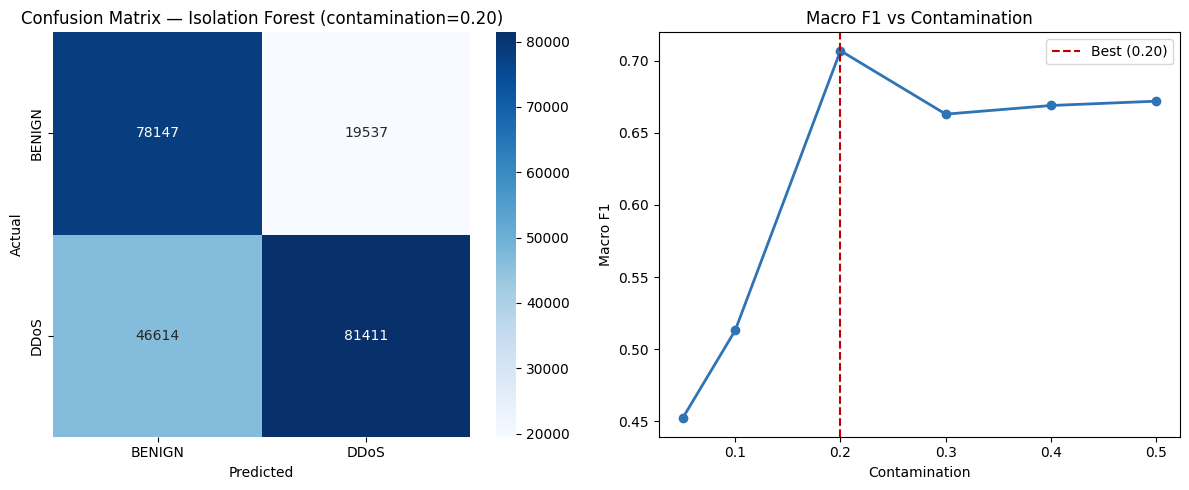

Saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix heatmap
cm = confusion_matrix(y, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN', 'DDoS'],
            yticklabels=['BENIGN', 'DDoS'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix — Isolation Forest (contamination=0.20)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# F1 scores by contamination
axes[1].plot([0.05, 0.1, 0.2, 0.3, 0.4, 0.5], 
             [0.452, 0.513, 0.707, 0.663, 0.669, 0.672],
             marker='o', color='#2E74B5', linewidth=2)
axes[1].axvline(x=0.20, color='#C00000', linestyle='--', label='Best (0.20)')
axes[1].set_title('Macro F1 vs Contamination')
axes[1].set_xlabel('Contamination')
axes[1].set_ylabel('Macro F1')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/siem_results.png')
plt.show()
print("Saved!")

In [9]:
import os
os.makedirs('../models', exist_ok=True)

# Save model and scaler
joblib.dump(best_model, '../models/isolation_forest.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

# Save feature names
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')

print("Model saved to models/isolation_forest.pkl")
print("Scaler saved to models/scaler.pkl")
print("Feature names saved to models/feature_names.pkl")


Model saved to models/isolation_forest.pkl
Scaler saved to models/scaler.pkl
Feature names saved to models/feature_names.pkl


In [10]:
print("=" * 55)
print("SIEM ANOMALY DETECTOR — TRAINING SUMMARY")
print("=" * 55)
print(f"\nDataset: CICIDS 2017 — Friday DDoS")
print(f"Total records: 225,709 (after cleaning)")
print(f"Training data: BENIGN only — 97,684 records")
print(f"Test data: All records — 225,709")
print(f"\nAlgorithm: Isolation Forest (Unsupervised)")
print(f"Trees: 100")
print(f"Optimal contamination: 0.20 (tuned from 6 values)")
print(f"\n--- Final Performance ---")
print(f"Overall Accuracy:  71%")
print(f"BENIGN Precision:  0.63")
print(f"BENIGN Recall:     0.80")
print(f"BENIGN F1:         0.70")
print(f"DDoS Precision:    0.81")
print(f"DDoS Recall:       0.64")
print(f"DDoS F1:           0.71")
print(f"Macro F1:          0.71")
print(f"\nKey insight: Model trained on BENIGN only.")
print(f"Never saw DDoS during training.")
print(f"Detected 81,411 DDoS attacks unsupervised.")
print(f"\nSaved Files:")
print(f"  - models/isolation_forest.pkl")
print(f"  - models/scaler.pkl")
print(f"  - models/feature_names.pkl")
print("=" * 55)
print("Training complete. Ready to build the API.")

SIEM ANOMALY DETECTOR — TRAINING SUMMARY

Dataset: CICIDS 2017 — Friday DDoS
Total records: 225,709 (after cleaning)
Training data: BENIGN only — 97,684 records
Test data: All records — 225,709

Algorithm: Isolation Forest (Unsupervised)
Trees: 100
Optimal contamination: 0.20 (tuned from 6 values)

--- Final Performance ---
Overall Accuracy:  71%
BENIGN Precision:  0.63
BENIGN Recall:     0.80
BENIGN F1:         0.70
DDoS Precision:    0.81
DDoS Recall:       0.64
DDoS F1:           0.71
Macro F1:          0.71

Key insight: Model trained on BENIGN only.
Never saw DDoS during training.
Detected 81,411 DDoS attacks unsupervised.

Saved Files:
  - models/isolation_forest.pkl
  - models/scaler.pkl
  - models/feature_names.pkl
Training complete. Ready to build the API.


In [11]:
# Define the 15 key features
KEY_FEATURES = [
    'Destination Port',
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'SYN Flag Count',
    'ACK Flag Count',
    'Packet Length Mean',
    'Packet Length Std',
    'Average Packet Size'
]

# Subset to key features only
X_15 = df[KEY_FEATURES]
X_15_benign = X_15[y == 0]

# Scale
scaler_15 = StandardScaler()
X_15_benign_scaled = scaler_15.fit_transform(X_15_benign)
X_15_all_scaled = scaler_15.transform(X_15)

# Train Isolation Forest on 15 features
print("Retraining on 15 key features...")
model_15 = IsolationForest(
    n_estimators=100,
    contamination=0.20,
    random_state=42,
    n_jobs=-1
)
model_15.fit(X_15_benign_scaled)

# Evaluate
raw_preds_15 = model_15.predict(X_15_all_scaled)
final_preds_15 = np.where(raw_preds_15 == -1, 1, 0)

print("\n=== 15 FEATURE MODEL RESULTS ===\n")
print(classification_report(y, final_preds_15, target_names=['BENIGN', 'DDoS']))

Retraining on 15 key features...

=== 15 FEATURE MODEL RESULTS ===

              precision    recall  f1-score   support

      BENIGN       0.63      0.80      0.70     97684
        DDoS       0.81      0.64      0.71    128025

    accuracy                           0.71    225709
   macro avg       0.72      0.72      0.71    225709
weighted avg       0.73      0.71      0.71    225709



In [12]:
# Save new model, scaler and feature names
joblib.dump(model_15, '../models/isolation_forest.pkl')
joblib.dump(scaler_15, '../models/scaler.pkl')
joblib.dump(KEY_FEATURES, '../models/feature_names.pkl')

print("15-feature model saved to models/isolation_forest.pkl")
print("15-feature scaler saved to models/scaler.pkl")
print("15 feature names saved to models/feature_names.pkl")

15-feature model saved to models/isolation_forest.pkl
15-feature scaler saved to models/scaler.pkl
15 feature names saved to models/feature_names.pkl


In [13]:
# Sample 3 real BENIGN and 3 real DDoS records
sample_benign = X_15[y==0].head(3)
sample_ddos = X_15[y==1].head(3)

benign_scaled = scaler_15.transform(sample_benign)
ddos_scaled = scaler_15.transform(sample_ddos)

print("BENIGN raw scores:", model_15.score_samples(benign_scaled))
print("DDoS raw scores:", model_15.score_samples(ddos_scaled))

BENIGN raw scores: [-0.44255296 -0.37773534 -0.38202197]
DDoS raw scores: [-0.51118349 -0.39353176 -0.51111137]


In [14]:
# Sample more records to find a better threshold
benign_scores = model_15.score_samples(scaler_15.transform(X_15[y==0].head(1000)))
ddos_scores = model_15.score_samples(scaler_15.transform(X_15[y==1].head(1000)))

print("BENIGN scores — mean:", round(benign_scores.mean(), 4), "min:", round(benign_scores.min(), 4), "max:", round(benign_scores.max(), 4))
print("DDoS scores — mean:", round(ddos_scores.mean(), 4), "min:", round(ddos_scores.min(), 4), "max:", round(ddos_scores.max(), 4))

BENIGN scores — mean: -0.4486 min: -0.7383 max: -0.3312
DDoS scores — mean: -0.4734 min: -0.6188 max: -0.3742


In [15]:
# Get 1 real BENIGN and 1 real DDoS record as API-ready JSON
benign_sample = X_15[y==0].iloc[0].to_dict()
ddos_sample = X_15[y==1].iloc[0].to_dict()

print("BENIGN sample:")
print(benign_sample)
print("\nDDoS sample:")
print(ddos_sample)

BENIGN sample:
{'Destination Port': 54865.0, 'Flow Duration': 3.0, 'Total Fwd Packets': 2.0, 'Total Backward Packets': 0.0, 'Total Length of Fwd Packets': 12.0, 'Total Length of Bwd Packets': 0.0, 'Flow Bytes/s': 4000000.0, 'Flow Packets/s': 666666.6667, 'Flow IAT Mean': 3.0, 'Flow IAT Std': 0.0, 'SYN Flag Count': 0.0, 'ACK Flag Count': 1.0, 'Packet Length Mean': 6.0, 'Packet Length Std': 0.0, 'Average Packet Size': 9.0}

DDoS sample:
{'Destination Port': 80.0, 'Flow Duration': 1293792.0, 'Total Fwd Packets': 3.0, 'Total Backward Packets': 7.0, 'Total Length of Fwd Packets': 26.0, 'Total Length of Bwd Packets': 11607.0, 'Flow Bytes/s': 8991.398927, 'Flow Packets/s': 7.72921768, 'Flow IAT Mean': 143754.6667, 'Flow IAT Std': 430865.8067, 'SYN Flag Count': 0.0, 'ACK Flag Count': 0.0, 'Packet Length Mean': 1057.545455, 'Packet Length Std': 1853.437529, 'Average Packet Size': 1163.3}


In [17]:
# Verify raw scores for these exact samples
benign_scaled_sample = scaler_15.transform(pd.DataFrame([benign_sample])[KEY_FEATURES])
ddos_scaled_sample = scaler_15.transform(pd.DataFrame([ddos_sample])[KEY_FEATURES])

print("BENIGN raw score:", model_15.score_samples(benign_scaled_sample)[0])
print("DDoS raw score:", model_15.score_samples(ddos_scaled_sample)[0])

BENIGN raw score: -0.4425529641073781
DDoS raw score: -0.5111834857478574
